In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: torch.flatten(x)) # Flatten 28x28 to 784
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_subset = torch.utils.data.Subset(train_dataset, range(5000))

100%|██████████| 9.91M/9.91M [00:11<00:00, 887kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 118kB/s]
100%|██████████| 1.65M/1.65M [00:03<00:00, 441kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.84MB/s]


In [ ]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(784, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
        
    def forward(self, x):
        return self.layers(x)

In [ ]:
def train_model(optimizer_name, batch_size=64, learning_rate=0.01, epochs=10):
    torch.manual_seed(42)
    model = SimpleMLP()
    criterion = nn.CrossEntropyLoss()
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)
    
    loss_history = []
    
    print(f"Training with {optimizer_name}...")
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        avg_loss = epoch_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")
        
    return loss_history

results = {}
results['SGD'] = train_model('SGD', learning_rate=0.01)
results['Adam'] = train_model('Adam', learning_rate=0.001) # Adam usually needs lower LR
results['RMSprop'] = train_model('RMSprop', learning_rate=0.001)

Training with SGD...
Epoch 1/10 - Loss: 1.7684
Epoch 2/10 - Loss: 0.9561
Epoch 3/10 - Loss: 0.6468
Epoch 4/10 - Loss: 0.5126
Epoch 5/10 - Loss: 0.4381
Epoch 6/10 - Loss: 0.4003
Epoch 7/10 - Loss: 0.3641
Epoch 8/10 - Loss: 0.3417
Epoch 9/10 - Loss: 0.3225
Epoch 10/10 - Loss: 0.3100
Training with Adam...
Epoch 1/10 - Loss: 0.8017
Epoch 2/10 - Loss: 0.3245
Epoch 3/10 - Loss: 0.2474
Epoch 4/10 - Loss: 0.2012
Epoch 5/10 - Loss: 0.1645
Epoch 6/10 - Loss: 0.1410
Epoch 7/10 - Loss: 0.1233
Epoch 8/10 - Loss: 0.1067
Epoch 9/10 - Loss: 0.0910
Epoch 10/10 - Loss: 0.0742
Training with RMSprop...
Epoch 1/10 - Loss: 0.5904
Epoch 2/10 - Loss: 0.2947
Epoch 3/10 - Loss: 0.2301
Epoch 4/10 - Loss: 0.1918
Epoch 5/10 - Loss: 0.1611
Epoch 6/10 - Loss: 0.1401
Epoch 7/10 - Loss: 0.1196
Epoch 8/10 - Loss: 0.1019
Epoch 9/10 - Loss: 0.0886
Epoch 10/10 - Loss: 0.0773


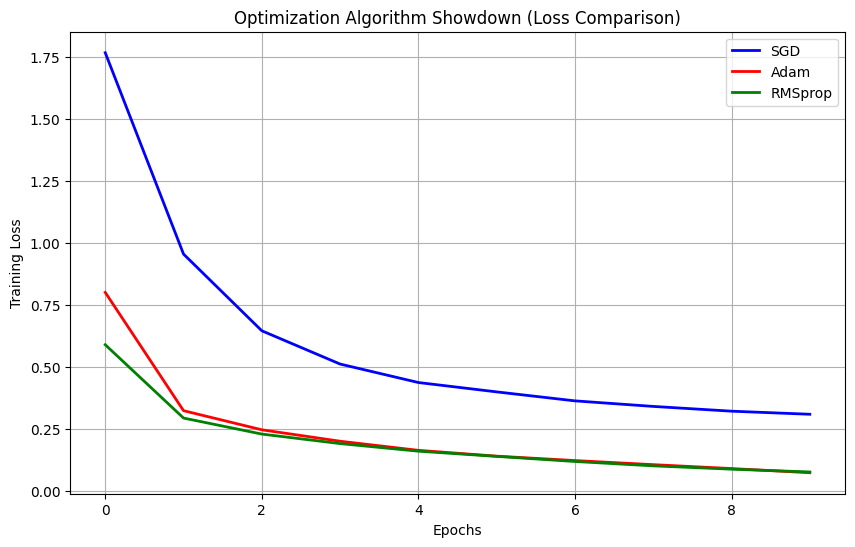

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(results['SGD'], label='SGD', color='blue', linewidth=2)
plt.plot(results['Adam'], label='Adam', color='red', linewidth=2)
plt.plot(results['RMSprop'], label='RMSprop', color='green', linewidth=2)

plt.title('Optimization Algorithm Showdown (Loss Comparison)')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.legend()
plt.grid(True)
plt.show()